# Preliminary Benchmark Development and Solver Analysis for 0-1 Knapsack Problems

This notebook documents the preliminary development of a benchmark framework for studying algorithm selection in 0-1 knapsack problems.

The current study compares two baseline solvers:

- Greedy heuristic solver
- Dynamic programming exact solver

The objectives are:

1. Develop reproducible optimization problem instances.
2. Evaluate solver performance under different problem characteristics.
3. Identify limitations of the current benchmark for future algorithm selection research.

This work serves as an initial step toward developing uncertainty-aware algorithm selection methods, where algorithm performance is analyzed under different problem characteristics.

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

import os

## 1. Initial Benchmark (Version 1)

The initial benchmark was designed with:

- Fixed problem size:
  - 50 items

- Fixed capacity ratio:
  - 0.5 of total item weights

- Three correlation structures:
  - uncorrelated
  - weak correlation
  - strong correlation

This provided an initial validation of the solver evaluation pipeline.

In [80]:
df = pd.read_csv("../results/solver_results.csv")
df.head()

,id,correlation,n_items,capacity,greedy_profit,dp_profit,gap,greedy_time,dp_time
0,0,uncorrelated,50,1324,1778,1778,0.000000,0.000182,0.041364
1,1,weak,50,1108,2039,2053,0.006819,0.000081,0.035864
2,2,strong,50,1366,3112,3125,0.004160,0.000108,0.043063
3,3,uncorrelated,50,1120,2028,2041,0.006369,0.000079,0.035503
4,4,weak,50,1238,2206,2209,0.001358,0.000079,0.040835


In [81]:
df.shape

(100, 9)

## Dataset Overview

In [82]:
df.describe()

,id,n_items,capacity,greedy_profit,dp_profit,gap,greedy_time,dp_time
count,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,50.0,1240.140000,2357.270000,2368.190000,0.004436,0.000082,0.040370
std,29.011492,0.0,101.135674,397.383382,401.469188,0.004701,0.000019,0.003747
min,0.000000,50.0,987.000000,1692.000000,1692.000000,0.000000,0.000061,0.031256
25%,24.750000,50.0,1185.250000,2070.500000,2074.250000,0.000436,0.000072,0.038286
50%,49.500000,50.0,1247.000000,2221.500000,2231.500000,0.002511,0.000075,0.040618
75%,74.250000,50.0,1295.750000,2692.500000,2729.000000,0.006888,0.000082,0.042642
max,99.000000,50.0,1526.000000,3119.000000,3131.000000,0.018975,0.000183,0.053961


## Solution Quality Comparison

Dynamic programming provides optimal solutions,
while greedy provides faster approximate solutions.

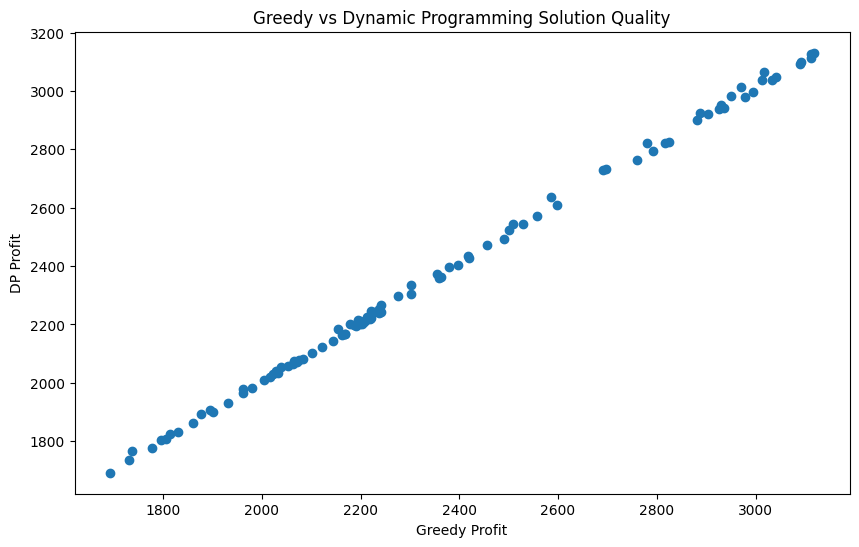

In [83]:
plt.figure(figsize=(10, 6))

plt.scatter(df["greedy_profit"], df["dp_profit"])

plt.xlabel("Greedy Profit")
plt.ylabel("DP Profit")
plt.title("Greedy vs Dynamic Programming Solution Quality")

plt.show()

## Optimality Gap Analysis

The optimality gap measures how close the greedy solution is compared with the exact solution.

$$
Gap=
\frac{P_{DP}-P_{Greedy}}
{P_{DP}}
$$

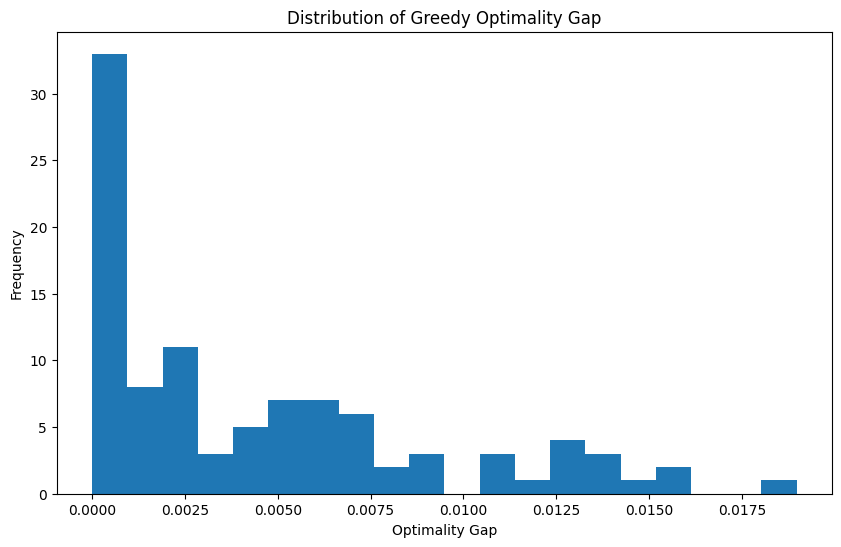

In [84]:
plt.figure(figsize=(10, 6))

plt.hist(df["gap"], bins=20)

plt.xlabel("Optimality Gap")
plt.ylabel("Frequency")
plt.title("Distribution of Greedy Optimality Gap")

plt.show()

## Computational Runtime Comparison

Greedy achieves significantly lower computational cost,
while dynamic programming provides exact solutions.

In [85]:
runtime_df = df[["greedy_time", "dp_time"]]

runtime_df.mean()

greedy_time    0.000082
dp_time        0.040370
dtype: float64

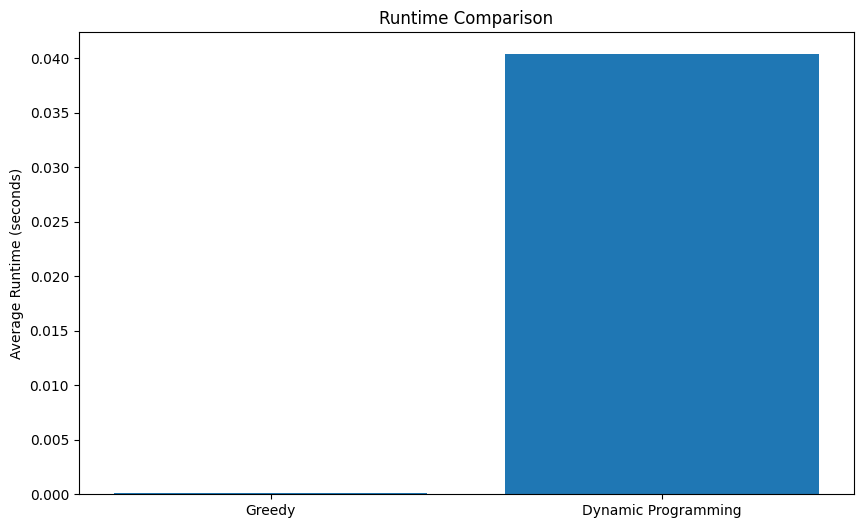

In [86]:
plt.figure(figsize=(10, 6))

plt.bar(["Greedy", "Dynamic Programming"], [df["greedy_time"].mean(), df["dp_time"].mean()])

plt.ylabel("Average Runtime (seconds)")
plt.title("Runtime Comparison")

plt.show()

### Initial Observation

The initial benchmark showed a highly imbalanced solver preference distribution.

Although dynamic programming provides optimal solutions, the generated instances resulted in greedy solutions achieved equal or near-optimal performance in most generated cases.

This suggested that the initial benchmark distribution was insufficiently diverse for studying algorithm selection behaviour.

## 2. Benchmark v2 Design

To improve benchmark diversity, the second version introduced variations in four dimensions:

### Problem Size

Different numbers of items were considered:

- 50
- 100
- 200


### Capacity Constraint

The capacity ratio was sampled from:

\[
0.1 \leq C/\sum w_i \leq 0.9
\]


### Weight-Profit Correlation

Four correlation structures were generated:

- uncorrelated
- weak
- strong
- inverse


### Instance Diversity

Random seeds were used to generate independent problem instances, reducing dependence on a single synthetic distribution.

The goal was to create a more representative benchmark distribution for future algorithm selection experiments.

In [87]:
import pickle
from collections import Counter
import numpy as np


with open("../data/knapsack_dataset_v2.pkl","rb") as f:
    dataset_v2 = pickle.load(f)

In [88]:
print("Number of instances:",len(dataset_v2))

Number of instances: 500


In [89]:
correlations=[
    x["correlation"]
    for x in dataset_v2
]

Counter(correlations)

Counter({'uncorrelated': 135, 'strong': 124, 'weak': 121, 'inverse': 120})

In [90]:
n_items=[
    len(x["weights"])
    for x in dataset_v2
]

Counter(n_items)

Counter({50: 262, 100: 157, 200: 81})

In [91]:
capacity_ratios=[
    x["capacity"]/np.sum(x["weights"])
    for x in dataset_v2
]


(
min(capacity_ratios),
max(capacity_ratios),
np.mean(capacity_ratios)
)

(0.10270482163857311, 0.8999272197962155, 0.50448128595307)

In [92]:
summary = pd.DataFrame({
    "Feature":[
        "Number of instances",
        "Problem sizes",
        "Correlation types",
        "Capacity ratio range"
    ],
    "Value":[
        "500",
        "50 / 100 / 200",
        "uncorrelated, weak, strong, inverse",
        "0.1 - 0.9"
    ]
})

summary

,Feature,Value
0,Number of instances,500
1,Problem sizes,50 / 100 / 200
2,Correlation types,"uncorrelated, weak, strong, inverse"
3,Capacity ratio range,0.1 - 0.9


## 3. Benchmark v2 Preliminary Solver Evaluation

The refined benchmark was evaluated using the same solver pipeline.

The evaluation metrics include:

- Solution quality difference
- Optimality gap
- Computational runtime

In [93]:
df_v2 = pd.read_csv(
    "../results/solver_results_v2.csv"
)

df_v2.head()

,id,correlation,n_items,capacity,greedy_profit,dp_profit,gap,greedy_time,dp_time,best_algorithm
0,0,strong,100,1180,2889,2903,0.004823,0.000349,0.072888,dp
1,1,uncorrelated,100,4106,5146,5146,0.000000,0.000133,0.267777,dp
2,2,uncorrelated,200,3428,6455,6459,0.000619,0.000166,0.447360,dp
3,3,inverse,50,827,2633,2634,0.000380,0.000086,0.025265,dp
4,4,inverse,100,795,3008,3008,0.000000,0.000086,0.047985,dp


In [94]:
df_v2.shape

(500, 10)

### Solver Preference Distribution

When selecting algorithms purely based on solution quality, dynamic programming becomes the dominant choice because it provides exact optimal solutions.

However, this ignores computational cost and practical constraints.

In [95]:
df_v2["best_algorithm"].value_counts()

best_algorithm
dp    500
Name: count, dtype: int64

## Runtime Comparison

Although dynamic programming provides optimal solutions, it requires significantly higher computational cost compared with the greedy heuristic.

In [96]:
df_v2[
    [
        "greedy_time",
        "dp_time"
    ]
].describe()

,greedy_time,dp_time
count,500.000000,500.000000
mean,0.000106,0.178177
std,0.000043,0.250340
min,0.000042,0.005605
25%,0.000079,0.035479
50%,0.000092,0.066080
75%,0.000118,0.213028
max,0.000349,1.183825


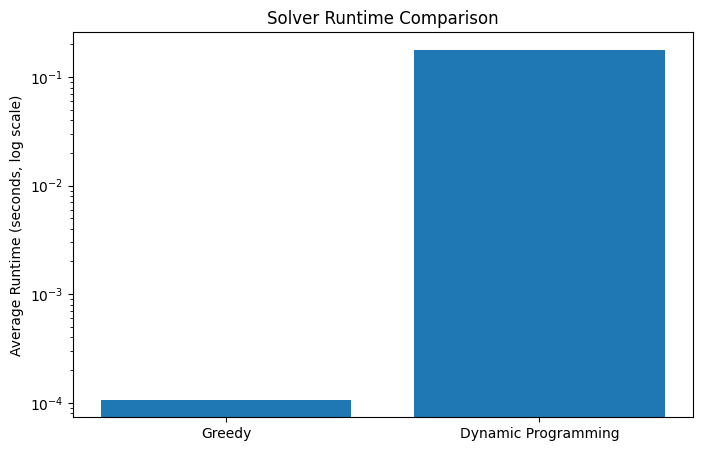

In [97]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Greedy","Dynamic Programming"],
    [
        df_v2["greedy_time"].mean(),
        df_v2["dp_time"].mean()
    ]
)

plt.yscale("log")

plt.ylabel("Average Runtime (seconds, log scale)")
plt.title("Solver Runtime Comparison")

plt.show()

## Solution Quality Analysis

The greedy heuristic achieves solutions close to the optimal dynamic programming solutions.


In [98]:
df_v2.groupby(
    "n_items"
)["gap"].mean()

n_items
50     0.004655
100    0.001799
200    0.000876
Name: gap, dtype: float64

In [99]:
df_v2.groupby(
    "correlation"
)["gap"].mean()

correlation
inverse         0.000546
strong          0.006572
uncorrelated    0.002132
weak            0.003345
Name: gap, dtype: float64

## Observation and Limitation

The preliminary benchmark demonstrates that solver evaluation based only on solution quality is insufficient for practical algorithm selection.

Dynamic programming achieves optimal solutions across the generated instances, while greedy heuristics provide competitive solutions with substantially lower computational cost.

Therefore, selecting algorithms requires considering multiple objectives, including:

- solution quality,
- computational efficiency,
- problem characteristics.

Future work will investigate whether instance-level features can provide useful signals for adaptive algorithm selection.

## Limitation of Profit-only Algorithm Selection

The previous solver comparison selected the best algorithm based only on solution quality.

Since dynamic programming is an exact optimization method, it achieves optimal solutions for all generated instances.

However, this definition leads to a trivial algorithm selection problem, where the same solver is always preferred.

In practical optimization scenarios, computational efficiency is also an important consideration. A solver providing slightly lower solution quality but significantly faster execution may be preferable under limited computational resources.

Therefore, a cost-aware algorithm selection objective is introduced.

## Cost-aware Algorithm Selection Formulation

To incorporate computational efficiency, a utility-based objective is introduced.

The selection score is defined as:

$$
Score = Profit - \lambda \times Runtime
$$

where:

- Profit represents solution quality.
- Runtime represents computational cost.
- λ controls the preference between solution quality and efficiency.

A larger λ indicates a stronger preference for faster algorithms.

## Sensitivity Analysis of λ

The value of λ determines the balance between solution quality and computational efficiency.

Different λ values were evaluated to investigate how solver preference changes under different computational constraints.

In [100]:
import pandas as pd

lambda_results = pd.DataFrame({
    "lambda": [
        100,
        500,
        1000,
        2000,
        5000
    ],
    "greedy": [
        331,
        439,
        474,
        491,
        500
    ],
    "dp": [
        169,
        61,
        26,
        9,
        0
    ]
})

lambda_results

,lambda,greedy,dp
0,100,331,169
1,500,439,61
2,1000,474,26
3,2000,491,9
4,5000,500,0


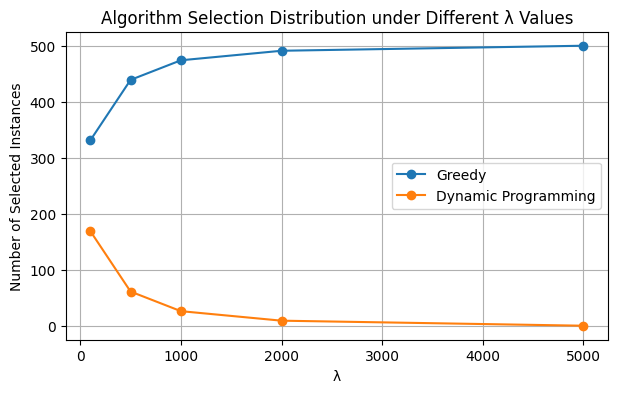

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    lambda_results["lambda"],
    lambda_results["greedy"],
    marker="o",
    label="Greedy"
)

plt.plot(
    lambda_results["lambda"],
    lambda_results["dp"],
    marker="o",
    label="Dynamic Programming"
)

plt.xlabel("λ")
plt.ylabel("Number of Selected Instances")

plt.title(
    "Algorithm Selection Distribution under Different λ Values"
)

plt.legend()

plt.grid(True)

plt.show()

## Selected Algorithm Selection Objective

Based on the sensitivity analysis, λ=100 was selected as the default setting.

This configuration provides a balanced distribution between greedy and dynamic programming selections:

- Greedy: 331 instances
- Dynamic programming: 169 instances

This avoids a degenerate single-class selection problem while maintaining the trade-off between solution quality and computational efficiency.

In [102]:
df_ml = pd.read_csv(
    "../results/algorithm_selection_dataset.csv"
)

print(df_ml.shape)

print(
    df_ml["best_algorithm"].value_counts()
)

(500, 9)
best_algorithm
greedy    331
dp        169
Name: count, dtype: int64


## Future Direction

The next stage will investigate learning-based algorithm selection models.

Instance-level features will be used to predict suitable algorithms, including:

- problem size,
- capacity characteristics,
- weight-profit distributions.

Furthermore, uncertainty estimation will be explored to quantify prediction confidence and identify difficult instances requiring further solver evaluation.